# Build Features from Waveform

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from bioacoustics.data import load_metadata, load_audio, save_results

from bioacoustics.features import (
    get_features,
    get_spectrogram,
    prepare_data,
    get_mel_spectrogram,
    get_mfcc,
    get_chroma_stft,
)

from bioacoustics.visualization import (
    plot_spectrogram,
    plot_waveform,
    plot_autocorrelation,
    plot_cepstrum_pipeline,
    plot_mfcc,
    plot_chroma_stft,
    plot_onsets
)


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load metadata and example audio

In [2]:
df_train, df_train_soundscapes, df_taxonomy = load_metadata()
example_audio = load_audio(df_train_soundscapes.iloc[0])
# example_audio = load_audio(df_train.iloc[0])

## Handcraft features

General idea is that an audio signal is a hierarchy of oscillations - the raw signal can be represented as a combination of oscillations in time (spectrogram), the frequency content at a given moment itself oscillates (e.g. harmonics), as well as the frequency band intensity oscillates in time (temporal patterns in songs, chirps). 

The aim of feature engineering is to compute proxies capturing those patterns. Deep learning pipelines usually apply CNN to (log-mel) spectrogram and learn to find those patterns.

Some of features can be easily computed with [`librosa.feature`](https://librosa.org/doc/0.11.0/feature.html).

### Raw signal features

We can directly extract from the raw waveform:
- mean
    - mean is supposed to be around 0 since sound oscillates around equilibrium pressure
    - weak feature and usually a recording artifact 
    - **so attention to bias!**
- std and RMS
    - correspond to signal amplitude - RMS to total energy
    - std = RMS when mean=0 
    - so they are partly redundant
- min, max
    - very instable feature
- raw waveform percentiles are not used (less meaningful)
- zero crossing rate 
    - how often signal changes sign over short windows
    - crude frequency estimate
    - its mean and std reflect average high-frequency activity and temporal variability 
    - percentiles focus on describing background / typical / intense regimes
- framewise RMS (across time)
    - frame mean, std, min, max
    - percentiles
    - reflects typical low, medium, high energy activity and how "bursty" the signal is

Biologically these features are rather scene descriptors.

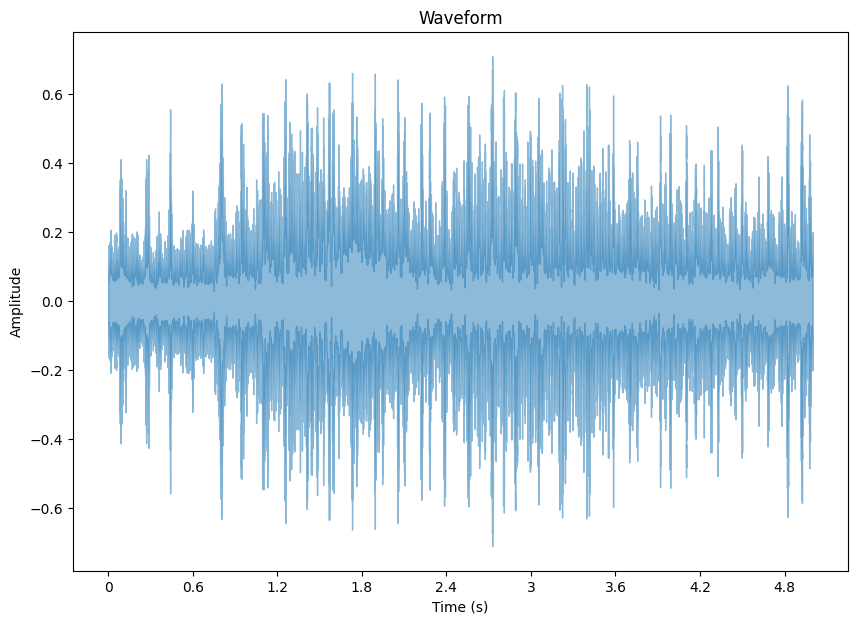

In [14]:
plot_waveform(example_audio)
plt.show()

### Spectrogram & spectral features

Now we want to analyze frequency content over time with Short Time Fourier Transform (STFT) giving a spectrogram. FT produces complex numbers, so we take the absolute value to keep only the amplitude and discard phase information. (NB: absolute value is called amplitude, it's square is called power / energy)

However, dominant frequencies are much more intense than weaker ones. So with fix this scaling issue with decibel transformation - logarithmic transformation with respect to some reference (here, strongest spectral magnitude). It is important biologically because hearing is approximately logarithmic and statistically because it compresses extreme values. And normalization wrt to a reference emphasizes spectral shape rather than absolute values.


- spectrogram mean
    - how dense spectrogram is (many vs few active frequencies)
- spectrogram std
    - sparse vs uniform texture
- spectrogram max
    - near 0dB due to normalization (so **not informative**)
- spectrogram min
    - reflects dynamic range, weak feature

Mean, std and percentiles for (framewise) spectral features:
- spectral centroid 
    - frequency "center of mass" 
    - which frequencies dominate
- spectral bandwidth
    - frequency spread around centroid (analogous to variance)
    - pure tones vs broadband textures
- spectral rolloff
    - frequency below which 85% of spectral energy exists
    - how far into high frequencies does the signal extend
    - more robust to isolated peaks
- spectral contrast
    - per frequency band (around 7)
    - measures difference between spectral peaks and valleys
    - good to identify peakiness / harmonic structure
- spectral flatness
    - near 0: tonal-like (e.g. tonal vocalizations)
    - near 1:  white-noise-like (e.g. insects / rain)


Good for scene characterization and broad taxonomic separation. But still ignore temporal patterns (melodic structure), frequency patterns (e.g. exact harmonics), polyphony issues.

Note that usually raw spectrogram-based deep learning beats handcrafted features...

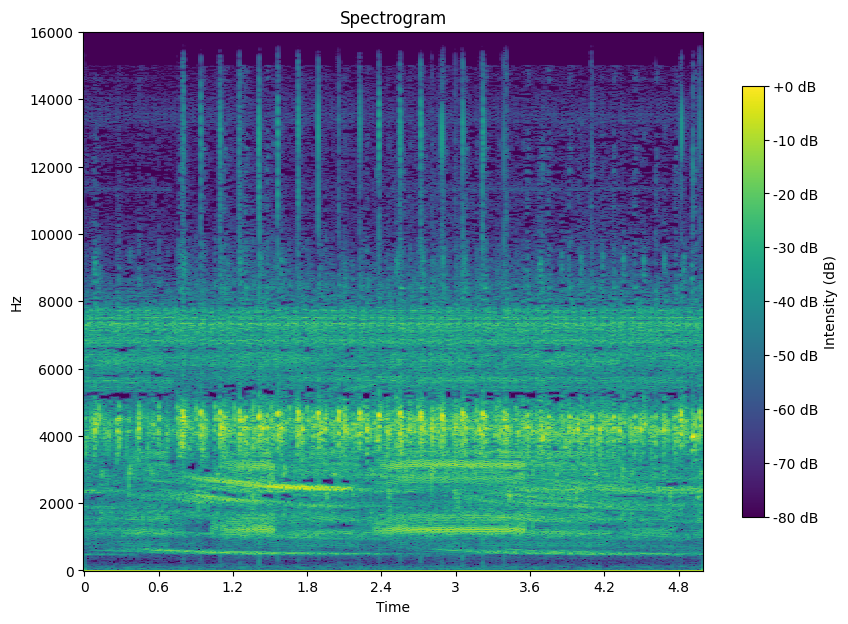

In [4]:
S_db, frequencies, times = get_spectrogram(example_audio)
plot_spectrogram(S_db)
plt.show()

### (Log)-Mel spectrogram

The spectrogram frequency can be scaled to reflect how **humans** perceive sound - better distinguish lower frequencies. 

`mel = 2595.0 * np.log10(1.0 + f / 700.0)` is established empirically.

Then mel filterbanks are applied to redefine bins - (around 80) overlapping triangular filters becoming more spaced for higher frequencies. So we get high resolutions for low frequencies, and compressed resolution for high frequencies.  

Extracted features:
- spectrogram mean, std 
    - e.g. low mean and high std can correspond to sparse peaks
- per band mean, std and percentiles
    - band = frequency channel across time
    - shows how active each frequency region is
    - highlights ecological niches - slightly addresses polyphony
    - mean - persistent occupancy, std - temporal intermittency
    - e.g. frogs - low, songbirds - min/high, insects - high frequencies

Obvious drawback is that **various species' perception does not coincide with this of humans**, e.g. birds and insects communicate in higher frequencies - so important regions may get over-compressed.

It destroys as well exact harmonics.

NB: decibel / log transformation is for spectral amplitude, mel is for frequency, so technically it is log-mel spectrogram (but people still say just mel).

Modern deep learning methods often take log-mel spectrogram as input.

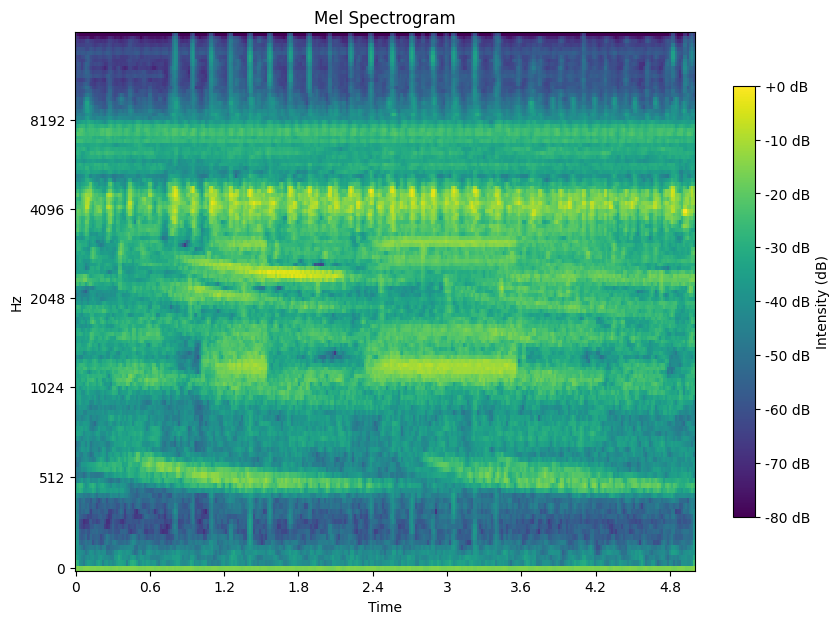

In [5]:
S_mel, frequencies, times = get_mel_spectrogram(example_audio)
plot_spectrogram(S_mel, title="Mel Spectrogram", y_axis="mel")
plt.show()

### Mel-Frequency Cepstral Coefficients

MFCC is used for compact timbre description - compressed summary of log-mel spectrogram. Classic from speech recognition. 

1. Take log-mel spectrogram
2. Discrete Cosine Transform
    - applied framewise
    - similar to DFT - re-express the spectrum shape as combinations of few smooth basis patterns
    - few basis patterns (around 20) - compresses the information
    - approximation of a cepstrum, capturing patterns in frequency variation at a given moment
    - so each MFCC coefficient is analogous to quefrency (frequency of frequencies)
    -  so these coefficients describe
        - MFCC 0: average spectral energy
        - MFCC 1: spectral tilt (slope)
        - MFCC 2: global curvature
        - Higher MFCCs: coarse oscillations

Extracted features:
- MFCC mean (across time)
    - which frequency patterns dominate over time
- MFCC std (across time)
    - changing acoustic events
- delta MFFCs mean and std across time
    - approximates temporal rate of change $\Delta c_t \approx c_t - c_{t-1}$
    - how each MFCC coefficient changes over time
    - mean captures trend in increasing vs decreasing spectral movement
    - std shows how dynamically it changes

However, MFCC assumes one speaker and **doesn't work good with polyphony**. Polyphony issue is better addressed by spectrogram CNNs or other neural methods.

Even though now we can capture spectral patterns of frequencies, but we **still don't detect temporal patterns**.

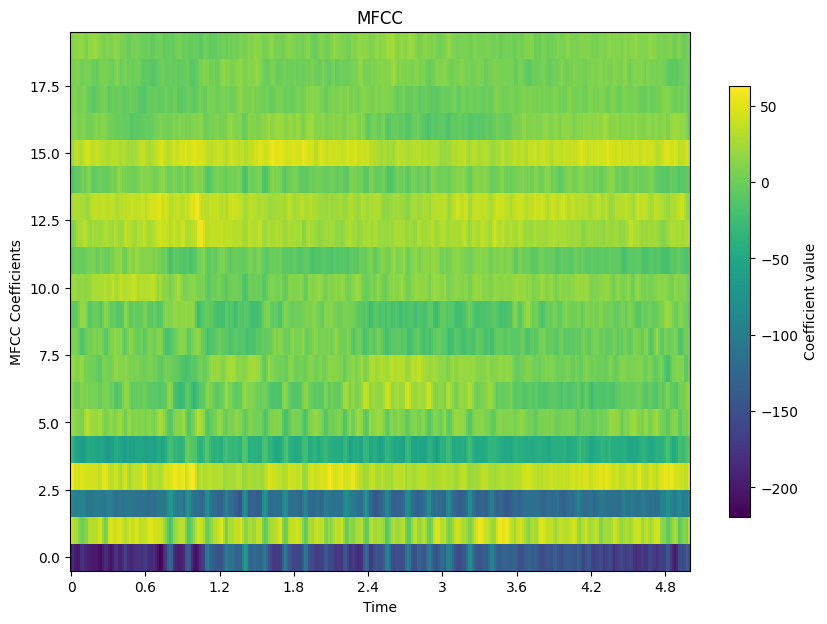

In [6]:
mfccs = get_mfcc(example_audio)
plot_mfcc(mfccs)
plt.show()

### Chroma features

Chroma compresses frequencies into pitch classes - notes modulo octave.

Extracted features: mean, std.

It is musically grounded and not really appropriate here, especially since it will cause collisions of multiple species occupying same pitch class on different octaves. It maybe useful however for highly harmonic vocalizations with octave invariance. We should try including / excluding it.


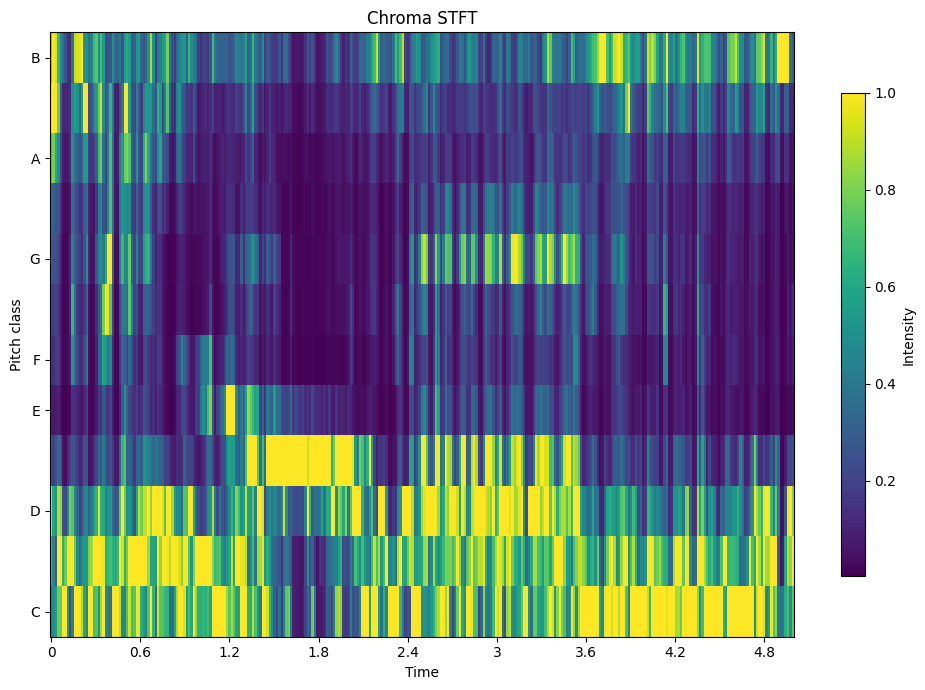

In [7]:
chroma_stft = get_chroma_stft(example_audio)
plot_chroma_stft(chroma_stft)
plt.show()

### Autocorrelation

Measures signal self-similarity over time. Primitive way to detect temporal repetition patterns.

Note that at lag 0, autocorrelation is equal to signal energy $R(0) = \sum_t{x(t)^2}$, at is maximal. So max of autocorrelation is redundant with RMS and not very informative.

But it doesn't work well with polyphony, it would be better to analyze temporal patterns per frequency band. It is as well $O(N^3)$, so FFT would be better, since it's $O(N \log N)$.

We decided to not use this feature and use modulation analysis instead. 

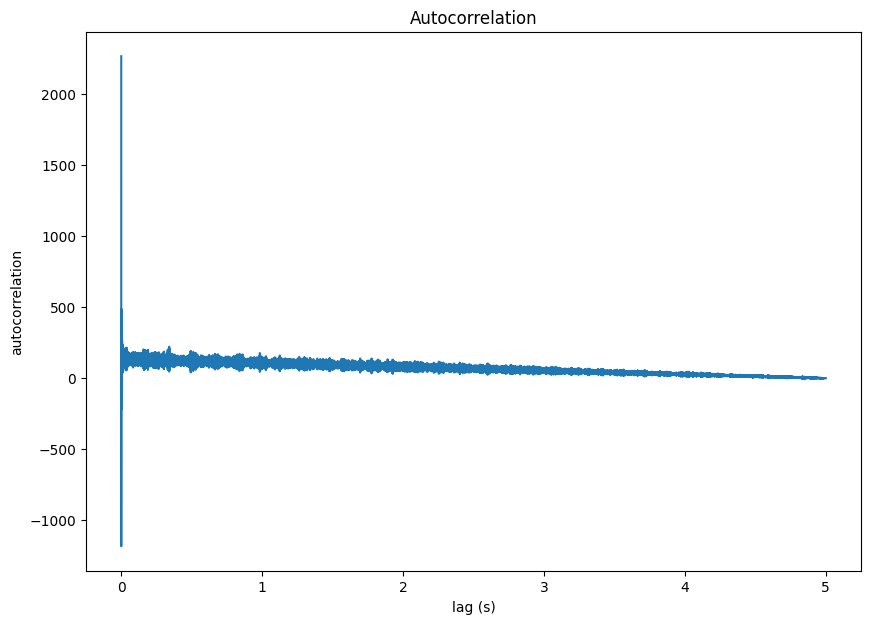

In [8]:
plot_autocorrelation(example_audio)

### Modulation spectrum analysis

Better way to analyze long-range temporal patterns, e.g. repeating chirps, trains, trills.. For each Mel band, analyze periodicity / modulation of temporal energy trajectory.

Terminology: carrier is the fast oscillation, modulation is the slower process controlling some aspect of carrier.

So we take Mel spectrum and compute FFT per frequency band, then extract:
- peak rate
    - peak frequency of the modulation FFT
    - DC component (index 0) is mean energy, discarded
- energy in slow and high fluctuations
- centroid
    - how fast this band fluctuate on average
- flatness
    - see spectral flatness
- rolloff
    - see spectral rolloff

### Event structure

We want to detect when something acoustically important begins. Onset is a sudden increase in energy - temporal event boundary.

Different species have different event timing.

Onset strength is defined by $\text{mean}_f \max(0, S[f, t] - ref[f, t - lag])$. It shows how strongly the *spectrogram* changes at each frame.

Extracted features:
- mean, std and percentiles of onset strength
    - average eventfulness and it's variability
- number of detected onsets
- inter-onset intervals (mean, std, percentiles)

TODO: can think about doing it per Mel band (to isolate acoustic niches and better distinguish species).

NB: you can as well try to analyze tempo, but it's more music-related (one global BPM).

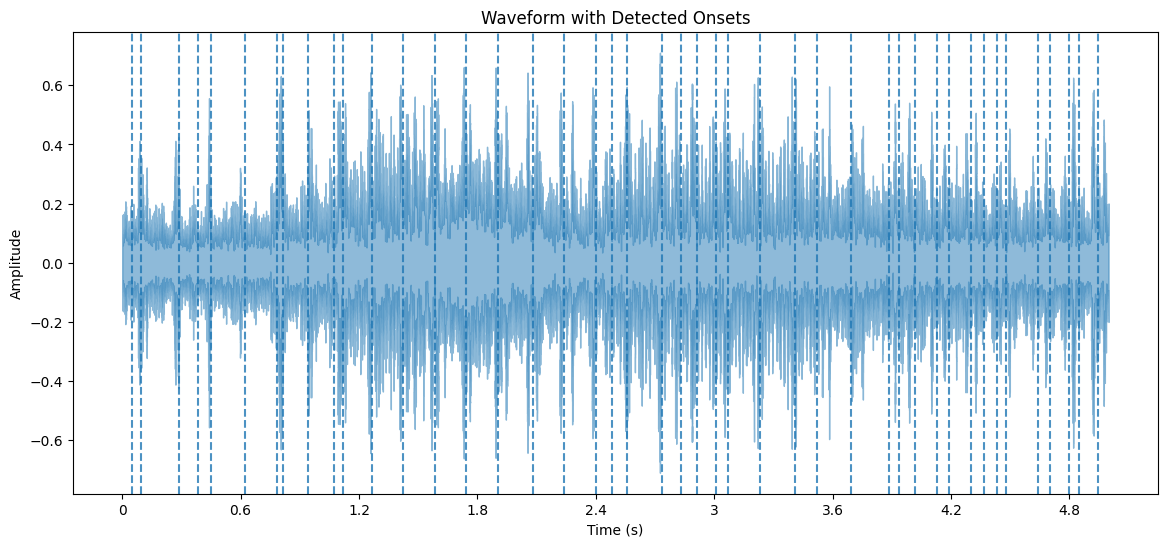

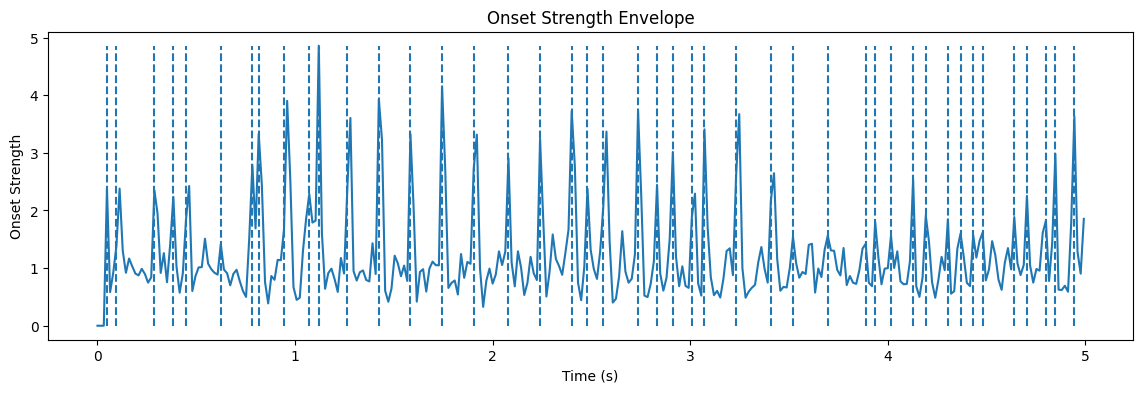

In [18]:
plot_onsets(example_audio)

### Example of all features collected for an audio:

In [22]:
get_features(example_audio)

mean                   0.029033
std                    0.115452
max                    0.710078
min                   -0.657333
rms                    0.119046
                         ...   
onset_interval_mean    0.113860
onset_interval_std     0.048581
onset_interval_p10     0.048000
onset_interval_p50     0.112000
onset_interval_p90     0.176000
Length: 381, dtype: float64

## Put together features and labels

In [ ]:
NB_EXAMPLES = 500  # ~ 250 samples / min
np.random.seed(42)
data_train = prepare_data(
    df_train, df_taxonomy, sample_idx=np.random.randint(0, len(df_train), NB_EXAMPLES)
)
np.random.seed(42)
data_train_soundscapes = prepare_data(
    df_train_soundscapes,
    df_taxonomy,
    sample_idx=np.random.randint(0, len(df_train_soundscapes), NB_EXAMPLES),
)

Extracting features:   0%|          | 0/500 [00:00<?, ?it/s]

## Save results

In [ ]:
save_results(data_train, "features", "data_train")
save_results(data_train_soundscapes, "features", "data_train_soundscapes")